# Recorte de enunciados de PDFs de emestrada — paso a paso

Este cuaderno hace lo mismo que `enunciados_batch.py`, pero dividido en celdas para que puedas ejecutar cada paso, ver qué ocurre y experimentar.

**Recorrido:**
1. Preparación (imports y rutas)
2. Explorar un PDF con pdfplumber
3. Encontrar los rectángulos de una página
4. Detectar el recuadro del enunciado (y quitar duplicados)
5. Recortar, extraer texto y guardar PNG
6. Extraer año, convocatoria y ejercicio con una expresión regular
7. Componer el PDF de salida con pypdf
8. Juntarlo todo en una función y procesar una carpeta completa

Ejecuta las celdas en orden con `Shift + Enter`.

## 1. Preparación

Si no tienes las librerías instaladas, descomenta y ejecuta la primera línea (solo hace falta una vez).

In [1]:
# %pip install pdfplumber pypdf pandas

import csv
import re
import unicodedata
from pathlib import Path

import pandas as pd
import pdfplumber
from pypdf import PdfReader, PdfWriter, Transformation
from IPython.display import display

### Rutas

Cambia estas tres rutas por las tuyas:
- `RUTA_PDF`: un PDF concreto para las pruebas de las secciones 2 a 7.
- `CARPETA_ENTRADA`: la carpeta con todos los PDF (sección 8).
- `CARPETA_SALIDA`: donde se guardarán los resultados.

In [7]:
RUTA_PDF = Path("../pdf_files/Química - Temas/equilibrio_químico/2026 - Equilibrio Químico.pdf")
CARPETA_ENTRADA = Path("pdfs")
CARPETA_SALIDA = Path("./pdf_recortados/")

CARPETA_SALIDA.mkdir(parents=True, exist_ok=True)
print("¿Existe el PDF de prueba?", RUTA_PDF.exists())

¿Existe el PDF de prueba? True


### Parámetros

Todas las medidas están en **puntos** (1 pt = 1/72 de pulgada ≈ 0,35 mm). Un A4 mide 595 × 842 pt.

In [8]:
ANCHO_MIN, ALTO_MIN = 300, 20   # tamaño mínimo para considerar un rectángulo como recuadro de enunciado
MARGEN = 2                      # holgura alrededor del borde al recortar
DPI = 200                       # resolución de los PNG
A4 = (595.28, 841.89)
MARGEN_A4 = 40                  # margen de la hoja de salida
SEPARACION = 15                 # hueco entre recuadros apilados

## 2. Explorar un PDF con pdfplumber

`pdfplumber.open()` abre el PDF. Lo dejamos abierto en la variable `pdf` para ir explorándolo en las celdas siguientes (lo cerraremos al final de la sección 5).

`pdf.pages` es la lista de páginas; la primera (índice 0) es la portada.

In [9]:
pdf = pdfplumber.open(RUTA_PDF)

print("Número de páginas:", len(pdf.pages))
page = pdf.pages[1]   # segunda página: el primer ejercicio
print("Tamaño de la página (ancho x alto, en pt):", page.width, "x", page.height)

Número de páginas: 3
Tamaño de la página (ancho x alto, en pt): 595.32 x 841.92


`page.to_image()` convierte la página en imagen para verla en el cuaderno. Es lo mismo que verías en un visor de PDF.

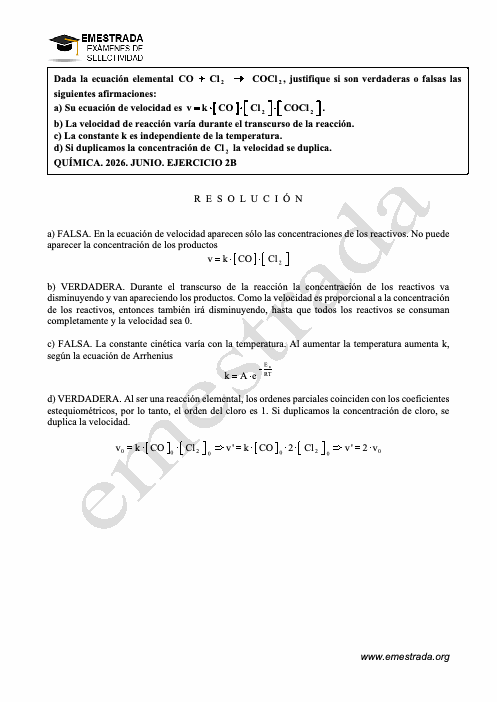

In [10]:
page.to_image(resolution=60)

## 3. Los rectángulos de la página

Un PDF es una lista de instrucciones de dibujo. pdfplumber nos da los objetos gráficos agrupados por tipo: `page.rects` (rectángulos), `page.lines` (líneas), `page.curves` (curvas) y `page.chars` (caracteres).

Cada rectángulo es un **diccionario**. Veamos el primero completo:

In [12]:
print("Rectángulos en la página:", len(page.rects))
# información del 1er rectángulo
page.rects[0]

Rectángulos en la página: 2


{'x0': 56.7,
 'y0': 633.12,
 'x1': 560.7,
 'y1': 760.82,
 'width': 504.00000000000006,
 'height': 127.70000000000005,
 'pts': [(56.7, 208.79999999999995),
  (560.7, 208.79999999999995),
  (560.7, 81.09999999999991),
  (56.7, 81.09999999999991)],
 'linewidth': 0,
 'stroke': False,
 'fill': True,
 'evenodd': True,
 'stroking_color': 0,
 'non_stroking_color': 1.0,
 'mcid': 44,
 'tag': 'P',
 'object_type': 'rect',
 'page_number': 2,
 'path': [('m', (56.7, 208.79999999999995)),
  ('l', (560.7, 208.79999999999995)),
  ('l', (560.7, 81.09999999999991)),
  ('l', (56.7, 81.09999999999991)),
  ('h',)],
 'dash': None,
 'top': 81.09999999999991,
 'bottom': 208.79999999999995,
 'doctop': 923.0199999999999}

Tiene muchas claves. Las que nos interesan son `x0`, `x1` (bordes izquierdo y derecho), `top`, `bottom` (distancias **desde arriba** de la página) y `width`, `height`.

Las pasamos a un DataFrame para verlas todas de un vistazo:

In [13]:
df_rects = pd.DataFrame(page.rects)[["x0", "top", "x1", "bottom", "width", "height", "fill", "stroke"]]
df_rects.round(1)

,x0,top,x1,bottom,width,height,fill,stroke
0,56.7,81.1,560.7,208.8,504.0,127.7,True,False
1,56.7,81.1,560.7,208.8,504.0,127.7,False,True


Fíjate en dos cosas:

- Hay rectángulos **grandes** (≈ 500 pt de ancho): el recuadro del enunciado. Los pequeños, si los hay, son otras cajas (por ejemplo las de "u = …; du = …" de las integrales por partes).
- El recuadro aparece **dos veces con las mismas coordenadas**: una es el relleno (`fill`) y otra el borde (`stroke`). Habrá que eliminar ese duplicado.

Podemos dibujar los rectángulos encima de la página para comprobarlo. `draw_rects()` los pinta en rojo:

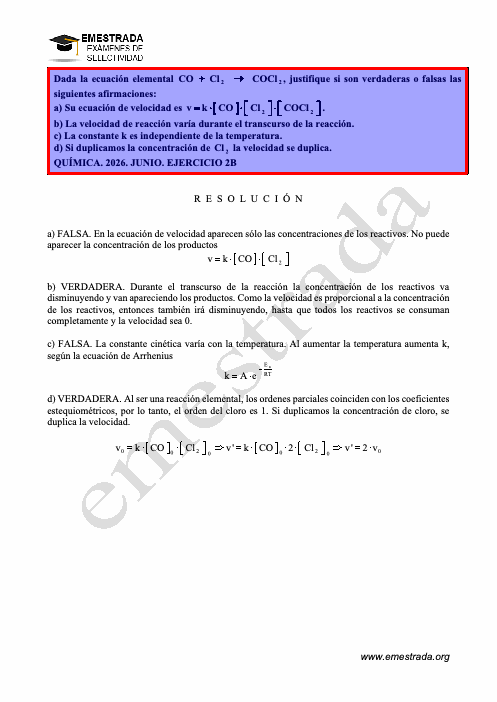

In [14]:
im = page.to_image(resolution=60)
im.draw_rects(page.rects, stroke="red", stroke_width=3)
im

## 4. Detectar el recuadro del enunciado

La función filtra por tamaño y elimina duplicados usando un diccionario cuya clave son las coordenadas redondeadas: si dos rectángulos están en el mismo sitio, el segundo sobrescribe al primero.

In [15]:
def detectar_recuadros(page):
    vistos = {}
    for r in page.rects:
        if r["width"] > ANCHO_MIN and r["height"] > ALTO_MIN:
            clave = tuple(round(r[k]) for k in ("x0", "top", "x1", "bottom"))
            vistos[clave] = r
    return sorted(vistos.values(), key=lambda r: r["top"])


cajas = detectar_recuadros(page)
print("Recuadros detectados:", len(cajas))
r = cajas[0]
print("Coordenadas:", {k: round(r[k], 1) for k in ("x0", "top", "x1", "bottom")})

Recuadros detectados: 1
Coordenadas: {'x0': 56.7, 'top': 81.1, 'x1': 560.7, 'bottom': 208.8}


Lo aplicamos a **todas** las páginas. La portada debería dar 0 y cada página de ejercicio, 1.

In [16]:
for n, p in enumerate(pdf.pages):
    print(f"Página {n + 1:2d}: {len(detectar_recuadros(p))} recuadro(s)")

Página  1: 0 recuadro(s)
Página  2: 1 recuadro(s)
Página  3: 1 recuadro(s)


## 5. Recortar, extraer texto y guardar PNG

`page.crop((x0, top, x1, bottom))` devuelve un objeto que se comporta como una página pero que solo "ve" lo que hay dentro de esa caja. Añadimos `MARGEN` puntos alrededor para no cortar el borde negro.

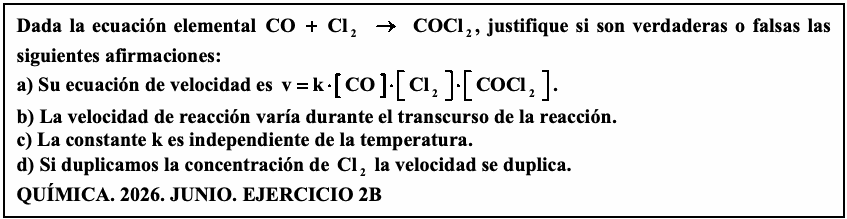

In [17]:
x0 = max(r["x0"] - MARGEN, 0)
x1 = min(r["x1"] + MARGEN, page.width)
top = max(r["top"] - MARGEN, 0)
bottom = min(r["bottom"] + MARGEN, page.height)

recorte = page.crop((x0, top, x1, bottom))
recorte.to_image(resolution=120)

### El texto del recorte

`extract_text()` devuelve el texto que hay dentro. Comprueba que las fórmulas salen mal (los símbolos de MathType aparecen como caracteres raros tipo `\uf0f2`), pero la **última línea** sale limpia. Esa línea es la que usaremos para los metadatos.

In [18]:
texto = recorte.extract_text()
print(texto)
print("\n--- Representación interna (repr) ---")
print(repr(texto))

Dada la ecuación elemental C O + C l
2
→ C O C l
2
, justifique si son verdaderas o falsas las
siguientes afirmaciones:
a) Su ecuación de velocidad es v = k   C O    C l
2
   C O C l
2
 .
b) La velocidad de reacción varía durante el transcurso de la reacción.
c) La constante k es independiente de la temperatura.
d) Si duplicamos la concentración de C l
2
la velocidad se duplica.
QUÍMICA. 2026. JUNIO. EJERCICIO 2B

--- Representación interna (repr) ---
'Dada la ecuación elemental C O + C l\n2\n→ C O C l\n2\n, justifique si son verdaderas o falsas las\nsiguientes afirmaciones:\na) Su ecuación de velocidad es v = k \uf0d7 \uf05b C O \uf05d \uf0d7 \uf0e9\uf0eb C l\n2\n\uf0f9\uf0fb \uf0d7 \uf0e9\uf0eb C O C l\n2\n\uf0f9\uf0fb .\nb) La velocidad de reacción varía durante el transcurso de la reacción.\nc) La constante k es independiente de la temperatura.\nd) Si duplicamos la concentración de C l\n2\nla velocidad se duplica.\nQUÍMICA. 2026. JUNIO. EJERCICIO 2B'


### Guardar el recorte como PNG

`to_image(resolution=...)` rasteriza el recorte y `.save()` lo escribe en disco.

In [19]:
carpeta_png = CARPETA_SALIDA / "png_pruebas"
carpeta_png.mkdir(parents=True, exist_ok=True)

destino = carpeta_png / "prueba.png"
recorte.to_image(resolution=DPI).save(destino)
print("Guardado en", destino)

Guardado en pdf_recortados/png_pruebas/prueba.png


## 6. Metadatos con una expresión regular

El patrón busca líneas como `MATEMÁTICAS II. 2023. RESERVA 1. EJERCICIO 3` o `QUÍMICA. 2000. JUNIO EJERCICIO 4. OPCIÓN A`. `(?P<nombre>...)` define grupos con nombre que luego se leen con `m["nombre"]`.

In [20]:
PATRON = re.compile(
    r"(?P<anio>(19|20)\d{2})\.\s*"
    r"(?P<conv>[A-ZÁÉÍÓÚ]+(?:\s+\d)?)\.?\s*"
    r"EJERCICIO\s*(?P<ej>\d+)"
    r"(?:\.?\s*OPCI[OÓ]N\s*(?P<opc>[AB]))?",
    re.IGNORECASE,
)

pruebas = [
    "MATEMÁTICAS II. 2023. RESERVA 1. EJERCICIO 3",
    "QUÍMICA. 2000. JUNIO EJERCICIO 4. OPCIÓN A",
    "QUÍMICA. 2010. SEPTIEMBRE. EJERCICIO 6. OPCIÓN B",
    "texto sin referencia",
]
for t in pruebas:
    m = PATRON.search(t)
    print(f"{t!r:55} ->", m.groupdict() if m else None)

'MATEMÁTICAS II. 2023. RESERVA 1. EJERCICIO 3'          -> {'anio': '2023', 'conv': 'RESERVA 1', 'ej': '3', 'opc': None}
'QUÍMICA. 2000. JUNIO EJERCICIO 4. OPCIÓN A'            -> {'anio': '2000', 'conv': 'JUNIO', 'ej': '4', 'opc': 'A'}
'QUÍMICA. 2010. SEPTIEMBRE. EJERCICIO 6. OPCIÓN B'      -> {'anio': '2010', 'conv': 'SEPTIEMBRE', 'ej': '6', 'opc': 'B'}
'texto sin referencia'                                  -> None


`slug()` convierte un texto en algo apto para nombre de archivo (sin tildes, sin espacios, en minúsculas):

In [21]:
def slug(texto):
    texto = unicodedata.normalize("NFKD", texto).encode("ascii", "ignore").decode()
    return re.sub(r"\W+", "_", texto).strip("_").lower()


print(slug("RESERVA 1"), "|", slug("SEPTIEMBRE"), "|", slug("2023 - Integrales"))

reserva_1 | septiembre | 2023_integrales


Lo aplicamos al texto real del recorte. Cambiamos los saltos de línea por espacios por si la referencia quedara partida en dos líneas.

In [22]:
m = PATRON.search(texto.replace("\n", " "))
nombre = f"{m['anio']}_{slug(m['conv'])}_ej{m['ej']}"
if m["opc"]:
    nombre += f"_{m['opc'].lower()}"
print("Metadatos:", m.groupdict())
print("Nombre de archivo:", nombre + ".png")

Metadatos: {'anio': '2026', 'conv': 'JUNIO', 'ej': '2', 'opc': None}
Nombre de archivo: 2026_junio_ej2.png


Y ahora para todas las páginas del PDF, para ver que funciona en todas:

In [23]:
for n, p in enumerate(pdf.pages):
    for r_ in detectar_recuadros(p):
        t = (p.crop((r_["x0"], r_["top"], r_["x1"], r_["bottom"])).extract_text() or "").replace("\n", " ")
        m_ = PATRON.search(t)
        print(f"Página {n + 1:2d}:", m_.groupdict() if m_ else "SIN METADATOS")

Página  2: {'anio': '2026', 'conv': 'JUNIO', 'ej': '2', 'opc': None}
Página  3: {'anio': '2026', 'conv': 'JUNIO', 'ej': '3', 'opc': None}


## 7. Componer el PDF de salida con pypdf

### 7.1. Cambio de coordenadas

pdfplumber mide la altura **desde arriba**; el formato PDF (y pypdf) **desde abajo**:

```
y_pdf = alto_pagina − y_pdfplumber
```

Por eso el borde inferior del recuadro en PDF es `alto − bottom` y el superior `alto − top`.

In [24]:
y0_pdf = page.height - bottom
y1_pdf = page.height - top
print(f"pdfplumber: top={top:.1f}, bottom={bottom:.1f}   (desde arriba)")
print(f"pypdf:      y0={y0_pdf:.1f}, y1={y1_pdf:.1f}   (desde abajo)")

pdfplumber: top=79.1, bottom=210.8   (desde arriba)
pypdf:      y0=631.1, y1=762.8   (desde abajo)


### 7.2. Recortar una página con pypdf

pypdf no borra contenido: cambia la **caja visible** de la página (`mediabox` y `cropbox`). Lo que queda fuera deja de verse.

Probamos con una sola página y la guardamos para verla:

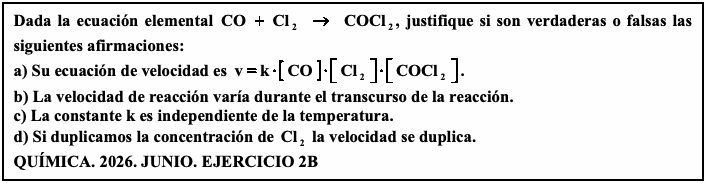

In [25]:
reader = PdfReader(RUTA_PDF)
src = reader.pages[1]
src.mediabox.lower_left = src.cropbox.lower_left = (x0, y0_pdf)
src.mediabox.upper_right = src.cropbox.upper_right = (x1, y1_pdf)

w, h = x1 - x0, y1_pdf - y0_pdf
writer = PdfWriter()
hoja = writer.add_blank_page(w, h)
hoja.merge_transformed_page(src, Transformation().translate(-x0, -y0_pdf))

prueba_pdf = CARPETA_SALIDA / "prueba_un_recuadro.pdf"
with open(prueba_pdf, "wb") as f:
    writer.write(f)

# Lo abrimos con pdfplumber solo para verlo aquí
with pdfplumber.open(prueba_pdf) as comprobacion:
    display(comprobacion.pages[0].to_image(resolution=100))

- `add_blank_page(w, h)` crea una hoja en blanco del tamaño del recuadro.
- `merge_transformed_page(src, t)` estampa la página recortada sobre la hoja, aplicándole antes la transformación `t`.
- `translate(-x0, -y0)` mueve el recuadro desde su posición original a la esquina (0, 0) de la hoja nueva.

### 7.3. Apilar todos los recuadros en hojas A4

Vamos colocando recuadros de arriba abajo. `y` indica la altura por la que vamos; cuando el siguiente no cabe, se crea una hoja nueva.

In [26]:
reader = PdfReader(RUTA_PDF)
writer = PdfWriter()
hoja, y = None, None

for n, p in enumerate(pdf.pages):
    for r_ in detectar_recuadros(p):
        # coordenadas con margen, convertidas a origen abajo
        cx0, cx1 = r_["x0"] - MARGEN, r_["x1"] + MARGEN
        cy0, cy1 = p.height - r_["bottom"] - MARGEN, p.height - r_["top"] + MARGEN

        src = reader.pages[n]
        src.mediabox.lower_left = src.cropbox.lower_left = (cx0, cy0)
        src.mediabox.upper_right = src.cropbox.upper_right = (cx1, cy1)

        escala = min(1.0, (A4[0] - 2 * MARGEN_A4) / (cx1 - cx0))
        w, h = (cx1 - cx0) * escala, (cy1 - cy0) * escala

        if hoja is None or y - h < MARGEN_A4:
            hoja = writer.add_blank_page(*A4)
            y = A4[1] - MARGEN_A4

        tx, ty = (A4[0] - w) / 2, y - h
        t = Transformation().translate(-cx0, -cy0).scale(escala, escala).translate(tx, ty)
        hoja.merge_transformed_page(src, t)
        y -= h + SEPARACION

salida_pdf = CARPETA_SALIDA / f"{RUTA_PDF.stem}_enunciados.pdf"
with open(salida_pdf, "wb") as f:
    writer.write(f)
print("Guardado:", salida_pdf, "| hojas:", len(writer.pages))

Guardado: pdf_recortados/2026 - Equilibrio Químico_enunciados.pdf | hojas: 1


Vista previa de la primera hoja:

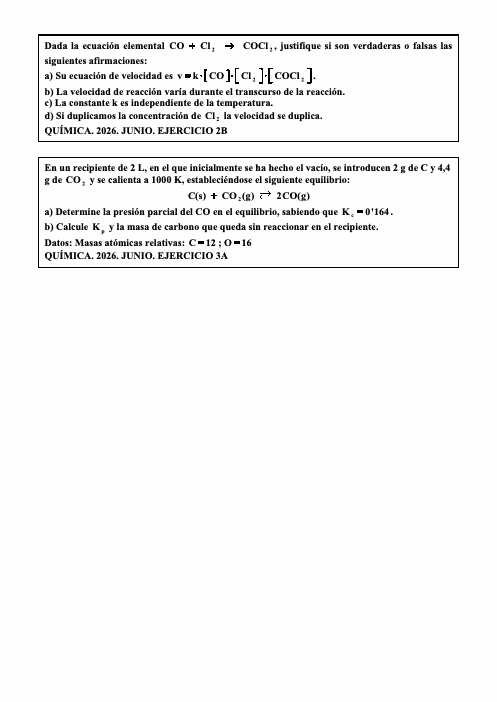

In [27]:
with pdfplumber.open(salida_pdf) as comprobacion:
    display(comprobacion.pages[0].to_image(resolution=60))

Cerramos el PDF de prueba que abrimos en la sección 2:

In [28]:
pdf.close()

## 8. Todo junto: procesar una carpeta completa

Ahora juntamos lo anterior en una función que procesa un PDF de principio a fin y devuelve las filas del índice. Es la misma lógica que en `enunciados_batch.py`.

Cambia `GUARDAR_PNG` y `UNO_POR_PAGINA` según lo que quieras.

In [ ]:
GUARDAR_PNG = True
UNO_POR_PAGINA = False


def procesar_pdf(ruta_pdf, carpeta_salida, png=GUARDAR_PNG, dpi=DPI, uno_por_pagina=UNO_POR_PAGINA):
    filas, recortes = [], []
    carpeta_png = carpeta_salida / "png" / ruta_pdf.stem

    # 1) Detección con pdfplumber
    with pdfplumber.open(ruta_pdf) as pdf:
        for n, page in enumerate(pdf.pages):
            cajas = detectar_recuadros(page)
            for k, r in enumerate(cajas, start=1):
                x0 = max(r["x0"] - MARGEN, 0)
                x1 = min(r["x1"] + MARGEN, page.width)
                top = max(r["top"] - MARGEN, 0)
                bottom = min(r["bottom"] + MARGEN, page.height)

                recorte = page.crop((x0, top, x1, bottom))
                texto = (recorte.extract_text() or "").replace("\n", " ")
                m = PATRON.search(texto)

                if m:
                    nombre = f"{m['anio']}_{slug(m['conv'])}_ej{m['ej']}"
                    if m["opc"]:
                        nombre += f"_{m['opc'].lower()}"
                else:
                    nombre = f"{slug(ruta_pdf.stem)}_p{n + 1:02d}"
                if len(cajas) > 1:
                    nombre += f"_r{k}"

                imagen = ""
                if png:
                    carpeta_png.mkdir(parents=True, exist_ok=True)
                    destino = carpeta_png / f"{nombre}.png"
                    i = 2
                    while destino.exists():
                        destino = carpeta_png / f"{nombre}_{i}.png"
                        i += 1
                    recorte.to_image(resolution=dpi).save(destino)
                    imagen = str(destino.relative_to(carpeta_salida))

                off_x, off_y = float(page.bbox[0]), float(page.bbox[1])
                recortes.append((n, off_x + x0, off_y + page.height - bottom,
                                 off_x + x1, off_y + page.height - top))

                aviso = ""
                if not m:
                    aviso = "sin metadatos"
                elif len(cajas) > 1:
                    aviso = f"{len(cajas)} recuadros en la página"

                filas.append({
                    "pdf": str(ruta_pdf),
                    "pagina_original": n + 1,
                    "anio": m["anio"] if m else "",
                    "convocatoria": m["conv"].title() if m else "",
                    "ejercicio": m["ej"] if m else "",
                    "opcion": (m["opc"] or "").upper() if m else "",
                    "pdf_salida": "",
                    "pagina_salida": "",
                    "imagen": imagen,
                    "aviso": aviso,
                })

    if not recortes:
        return filas, "ningún recuadro detectado"

    # 2) Composición vectorial con pypdf
    salida = carpeta_salida / f"{ruta_pdf.stem}_enunciados.pdf"
    writer = PdfWriter()
    hoja, y, num_hoja = None, None, 0
    usados = set()
    reader = PdfReader(ruta_pdf)

    for fila, (n, x0, y0, x1, y1) in zip(filas, recortes):
        # si la página ya se usó (varios recuadros), se relee para no pisar el recorte anterior
        src = (PdfReader(ruta_pdf) if n in usados else reader).pages[n]
        usados.add(n)
        src.mediabox.lower_left = src.cropbox.lower_left = (x0, y0)
        src.mediabox.upper_right = src.cropbox.upper_right = (x1, y1)
        w, h = x1 - x0, y1 - y0

        if uno_por_pagina:
            hoja = writer.add_blank_page(w, h)
            hoja.merge_transformed_page(src, Transformation().translate(-x0, -y0))
            num_hoja += 1
        else:
            escala = min(1.0, (A4[0] - 2 * MARGEN_A4) / w)
            w, h = w * escala, h * escala
            if hoja is None or y - h < MARGEN_A4:
                hoja = writer.add_blank_page(*A4)
                y = A4[1] - MARGEN_A4
                num_hoja += 1
            tx, ty = (A4[0] - w) / 2, y - h
            t = Transformation().translate(-x0, -y0).scale(escala, escala).translate(tx, ty)
            hoja.merge_transformed_page(src, t)
            y -= h + SEPARACION

        fila["pdf_salida"] = salida.name
        fila["pagina_salida"] = num_hoja

    with open(salida, "wb") as f:
        writer.write(f)
    return filas, ""

### 8.1. Probar la función con un solo PDF

In [ ]:
filas, aviso = procesar_pdf(RUTA_PDF, CARPETA_SALIDA)
print("Aviso:", aviso or "ninguno")
pd.DataFrame(filas)

### 8.2. Procesar la carpeta completa

`rglob("*.pdf")` busca PDF también en subcarpetas. Se excluyen los `_enunciados.pdf` que genera el propio proceso.

Aquí se procesan **uno detrás de otro**. Para lotes muy grandes, el script `enunciados_batch.py` es más rápido porque usa varios núcleos en paralelo (el procesamiento en paralelo no funciona bien dentro de Jupyter en Windows y macOS).

Si quieres probar primero con unos pocos, cambia `LIMITE` (por ejemplo, `LIMITE = 5`).

In [ ]:
LIMITE = None   # None = todos

pdfs = sorted(p for p in CARPETA_ENTRADA.rglob("*.pdf") if not p.stem.endswith("_enunciados"))
if LIMITE:
    pdfs = pdfs[:LIMITE]
print(f"{len(pdfs)} PDFs a procesar\n")

todas, problemas = [], []
for i, ruta in enumerate(pdfs, start=1):
    try:
        filas, aviso = procesar_pdf(ruta, CARPETA_SALIDA)
    except Exception as e:
        problemas.append({"pdf": str(ruta), "problema": f"ERROR: {e}"})
        print(f"[{i}/{len(pdfs)}] ERROR  {ruta.name}: {e}")
        continue
    todas.extend(filas)
    if aviso:
        problemas.append({"pdf": str(ruta), "problema": aviso})
        print(f"[{i}/{len(pdfs)}] AVISO  {ruta.name}: {aviso}")
    else:
        print(f"[{i}/{len(pdfs)}] OK     {ruta.name}: {len(filas)} enunciados")

### 8.3. Índice y revisión de problemas

Guardamos el índice en CSV y lo mostramos como DataFrame, que es cómodo para filtrar.

In [ ]:
indice = pd.DataFrame(todas)
indice.to_csv(CARPETA_SALIDA / "indice.csv", index=False, encoding="utf-8")
print("Total enunciados:", len(indice))
indice.head(20)

Enunciados con aviso (sin metadatos o varios recuadros por página) y PDFs con problemas:

In [ ]:
if len(indice):
    display(indice[indice["aviso"] != ""])
display(pd.DataFrame(problemas))

Un resumen rápido: cuántos enunciados hay por año y convocatoria.

In [ ]:
if len(indice):
    display(indice.pivot_table(index="anio", columns="convocatoria", values="ejercicio",
                               aggfunc="count", fill_value=0))